# Radial velocity analysis of WASP-12b 

**Universidad de La Laguna Exo & Exo 2025-2026 exercise 1**

Author: [Hannu Parviainen](mailto:hannu@iac.es)<br>
Last updated: 16.4.2026

This first exercise teaches you how to estimate the minimum planetary mass from radial velocity measurements using [Bayesian inference](https://en.wikipedia.org/wiki/Bayesian_inference).

**Exercise style:** 
- Use astropy constants, units, and unit conversions where possible.
- Carry out the calculations using posterior sample arrays instead of point estimates whenever possible. This ensures correct uncertainty propagation.


## 1.1 (The absolute basics of) radial velocities

A planet orbiting a star causes the star to [move around the star-planet barycentre](https://exoplanets.nasa.gov/alien-worlds/ways-to-find-a-planet/#/1). This leads to a periodic change in the star's position and velocity,
and the radial component of the star's velocity can be measured using [doppler spectroscopy](https://en.wikipedia.org/wiki/Doppler_spectroscopy). Radial velocity (RV) measurements are used to search for unknown planets and to estimate the minimum masses and orbital periods of known planets.

![Doppler shift vs time](Doppler_Shift_vs_Time.svg "Doppler shift vs time")


A planet with a mass $M_\mathrm{p}$ orbiting a star with a mass $M_\star$ with an orbital period $P$ leads to a periodic signal with a semi-amplitude of

$$
K = \left(\frac{2\pi G}{P}\right)^{1/3} \frac{M_\mathrm{p} \sin i}{(M_\star + M_\mathrm{p})^{2/3}} \frac{1}{(1-e^2)^{1/2}},
$$

where $G$ is the [gravitational constant](https://en.wikipedia.org/wiki/Gravitational_constant), $e$ is the [orbital eccentricity](https://en.wikipedia.org/wiki/Orbital_eccentricity), and $i$ is the [orbital inclination](https://en.wikipedia.org/wiki/Orbital_inclination). After we estimate $P$, $K$, and $M_\star$ we can solve for the minimum planetary mass $M_\mathrm{p} \sin i$. The orbital period and RV semi-amplitude can be estimated directly from the RV signal, but the stellar mass needs to be estimated using other means.


## 1.2 (The absolute basics of) Bayesian parameter estimation

Measuring the RV semi-amplitude and the orbital period from RV measurements is a *parameter estimation* problem: we assume we have an adequate model to describe the observations, and we want to infer the model parameters with their uncertainties.

We take a [*Bayesian*](http://en.wikipedia.org/wiki/Bayesian_probability) approach to the parameter estimation, where we want to estimate the [*posterior probability*](http://en.wikipedia.org/wiki/Posterior_probability) for the model parameters given their [*prior probabilities*](http://en.wikipedia.org/wiki/Prior_probability) and a set of observations. The posterior probability density given a parameter vector $\theta$ and observational data $D$ is described by the [*Bayes' theorem*](http://en.wikipedia.org/wiki/Bayes%27_theorem) as

$$
P(\theta|D) = \frac{P(\theta) P(D|\theta)}{P(D)}, \qquad P(D|\theta) = \prod P(D_i|\theta),
$$

where $P(\theta)$ is the prior, $P(D|\theta)$ is the [*likelihood*](http://en.wikipedia.org/wiki/Likelihood_function) for the data, and $P(D)$ is a [*normalising factor*](http://en.wikipedia.org/wiki/Marginal_likelihood) we don't need to bother with during MCMC-based parameter estimation. 

The likelihood is a product of individual observation probabilities, and has the unfortunate tendency to end up being either very small or very big. This causes computational headaches, and it is better to work with log probabilities instead, so that

$$
\log P(\theta|D) = \log P(\theta) + \log P(D|\theta),  \qquad \log P(D|\theta) = \sum \log P(D_i|\theta)
$$

where we have omitted the $P(D)$ term from the posterior density.

Now we still need to decide our likelihood density. If we can assume normally distributed white noise--that is, the errors in the observations are independent and identically distributed--we end up with a log likelihood function

$$
 \log P(D|\theta) = -N\log(\sigma) -\frac{N\log 2\pi}{2} - \sum_{i=0}^N \frac{(o_i-m_i)^2}{2\sigma^2},
$$

where $N$ is the number of datapoints, $\sigma$ is the white noise standard deviation, $o$ is the observed data, and $m$ is the model. 

This should be enough for these exercies, but you can find more information from [A primer about Bayesian statistics](https://ui.adsabs.harvard.edu/link_gateway/2018haex.bookE.149P/EPRINT_PDF) and the references therein.

## 2.1 Initialisation

In [3]:
import pandas as pd
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.pyplot import subplots, setp, rc, Rectangle
from numpy import argmax, median
from astropy.table import Table
from astropy.timeseries import LombScargle
from corner import corner

from pytransit.lpf.rvlpf import RVLPF

rc('figure', figsize=(13,4))

/home/alba/anaconda3/envs/exoexo/lib/python3.10/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(
/home/alba/anaconda3/envs/exoexo/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2.1 Read in the RV data 

The radial velocity measurements consist of mid-observation times, radial velocity values, and radial velocity measurement uncertainties (also called as 'errors'). We use the data from [Yee et al. (2019)](https://iopscience.iop.org/article/10.3847/2041-8213/ab5c16). The data is stored as a CDS table that can be read directly using `astropy.table.Table`.

In [4]:
rv_data = Table.read('data/wasp_12b_yee_2019.dat', format='ascii.cds')

It's important to understand what sort of data we're dealing with, so we begin by displaying the table header and the five first rows.

In [5]:
rv_data[:5]  

BJD,RVel,e_RVel
d,m / s,m / s
float64,float64,float64
2455521.959432,-136.635,2.534
2455543.089922,5.728,2.919
2455545.983884,-162.39,2.822
2455559.906718,141.616,2.345
2455559.917563,115.818,2.727


It's also useful to visualise directly what we're working with, so we next plot the radial velocity data and its uncertainties as a function of time.

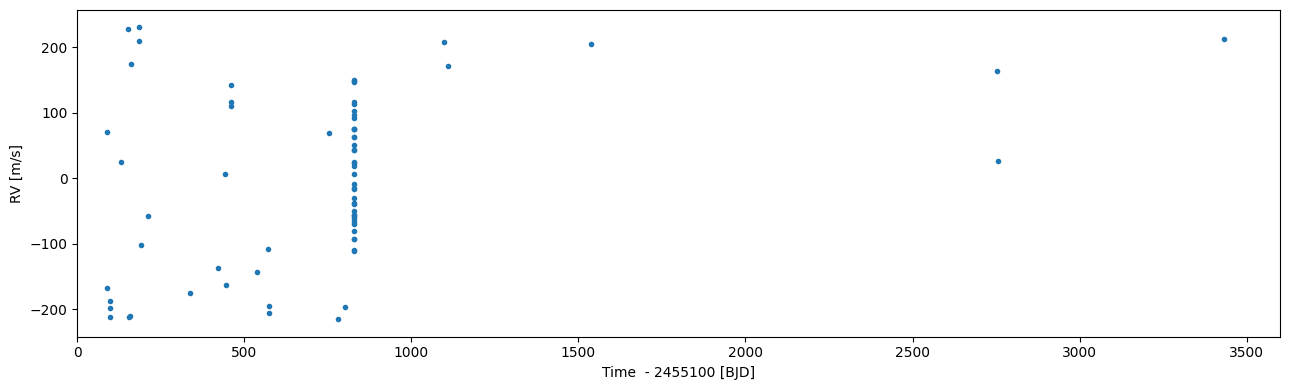

In [6]:
fig, ax = subplots()
ax.errorbar(rv_data['BJD'] - 2455100, rv_data['RVel'], rv_data['e_RVel'], fmt='.')
setp(ax, xlabel='Time  - 2455100 [BJD]', ylabel='RV [m/s]', xlim=(0, 3600))
fig.tight_layout()

### <span style="color:darkblue">Questions and exercises:</span>

1. Describe the logic behind the time sampling of the RV observations.

- As we can see in the RV graphic above, there are two types of samples, one dispersed sample along many years and another dense one. The first one is needed to fix the period and establish if there is any tendency through the years. The second one is used to cover a completed orbit and and determine de RV curve close to the maximum and minimum points, so is possible to calculate the K value.

2. Plot below the RV observations as a function of time focusing on the densely-sampled time-span.

       BJD        
        d         
------------------
421.95943199982867
 443.0899220001884
 445.9838840002194
 459.9067179998383
459.91756300022826
459.92785200010985
 536.8433019998483
  571.769904000219
 572.7718960000202
               ...
 129.8603389998898
150.86714199976996
155.80788599979132
156.89576500002295
160.81521400017664
 184.7867270000279
185.81402199994773
189.78859499981627
212.74383000005037
338.12822799989954
Length = 72 rows
BJD
 d 
---
 57
 58
 59
 60
 61
 62
 63
 64
 65
...
 47
 48
 49
 50
 51
 52
 53
 54
 55
 56
Length = 72 rows
28
Dense value window: 828.28 – 830.28 días


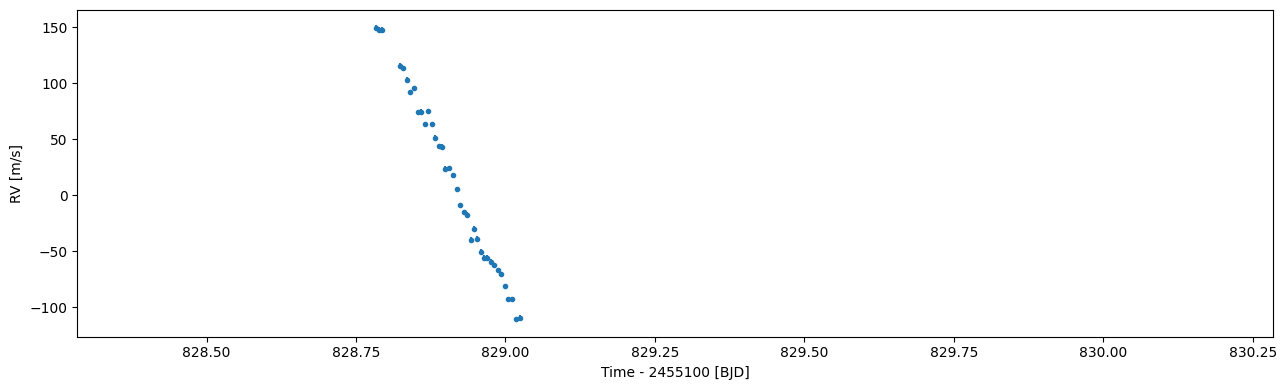

In [14]:
# Tiempo relativo
t = rv_data['BJD'] - 2455100
print(t)
rv = rv_data['RVel']
erv = rv_data['e_RVel']

# Ordenamos por tiempo
order = np.argsort(t)
print(order)
t_sorted = t[order]
rv_sorted = rv[order]
erv_sorted = erv[order]

# Buscamos el tramo más densamente muestreado en una ventana de W días
W = 2 * u.day  # 
W_value = W.to(u.day).value

counts = []
for ti in t_sorted:
    in_window = (t_sorted >= ti) & (t_sorted < ti + W_value)
    counts.append(np.sum(in_window))

imax = np.argmax(counts)
print(imax)
t0 = t_sorted[imax]-0.5
t1 = t0 + W_value

print(f"Dense value window: {t0:.2f} – {t1:.2f} días")

# Gráfico centrado en el tramo densamente muestreado
fig, ax = subplots()
mask = (t >= t0) & (t <= t1)

ax.errorbar(t[mask], rv[mask], erv[mask], fmt='.')
setp(ax,
     xlabel='Time - 2455100 [BJD]',
     ylabel='RV [m/s]',
     xlim=(t0, t1))
fig.tight_layout()


## 2.2 Search for a radial velocity signal

First, we use a Lomb-Scargle periodigram to search for a sinusoidial radial velocity signal from the RV measurements. This is simple to do with `astropy.timeseries.LombScargle` class that is initialised with the mid-measurement times and the RV observations.

In [15]:
ls = LombScargle(rv_data['BJD'], rv_data['RVel'])

Next, we use the `LombScargle.autopower` to calculate the periodogram. We restrict the search to $0.5 < P < 5$ days.

In [16]:
frequency, power = ls.autopower(minimum_frequency=1/(5*u.d), maximum_frequency=2/u.d)
period = 1/frequency

In [17]:
best_period = period[argmax(power)]
best_period

<Quantity 1.09144998 d>

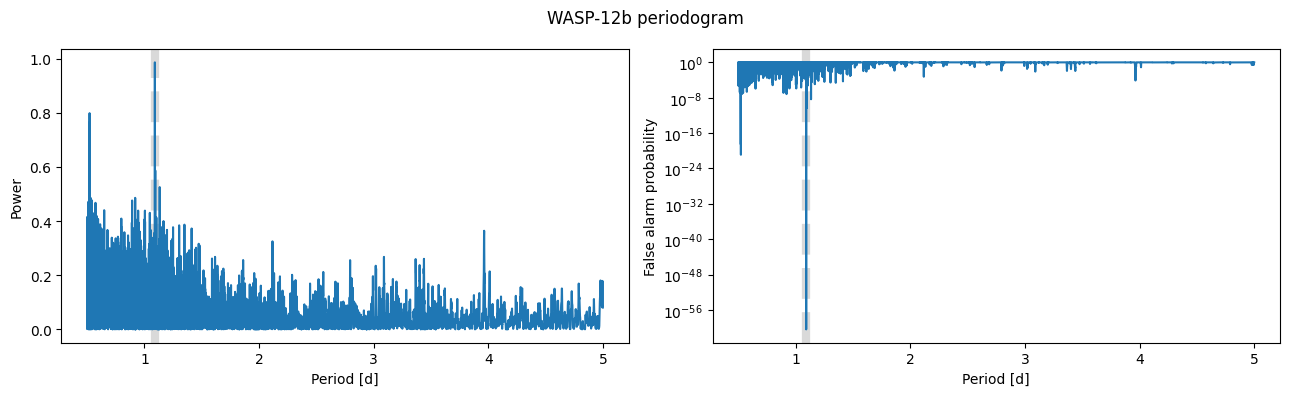

In [11]:
fig, axs = subplots(1, 2, figsize=(13,4))
axs[0].plot(period, power)
axs[1].semilogy(period, ls.false_alarm_probability(power))
[ax.axvline(best_period.value, c='k', ls='--', zorder=-1, lw=6, alpha=0.15) for ax in axs]
setp(axs, xlabel='Period [d]')
setp(axs[0], ylabel='Power')
setp(axs[1], ylabel='False alarm probability')
fig.suptitle('WASP-12b periodogram')
fig.tight_layout()

Let's see what happens when we plot the RV values folded over the best period.

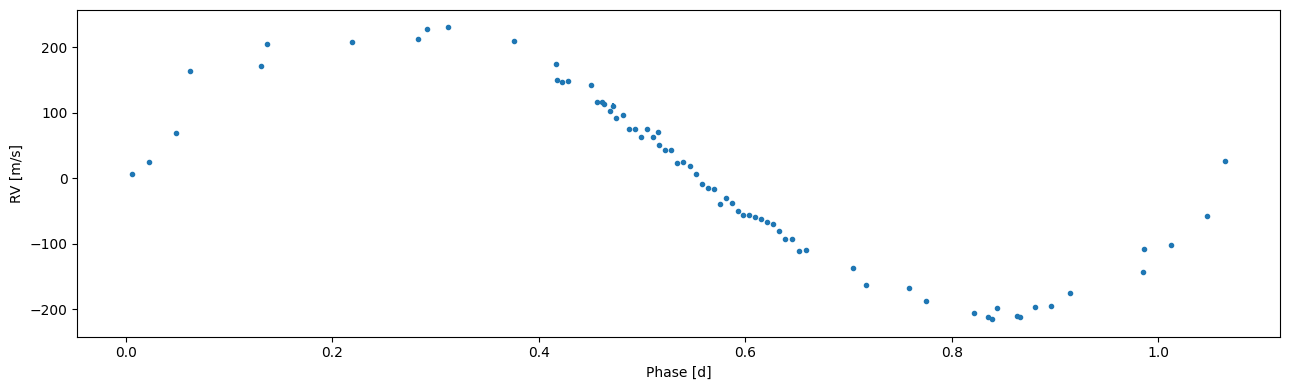

In [9]:
fig, ax = subplots()
ax.errorbar(rv_data['BJD'] % best_period.value, rv_data['RVel'], rv_data['e_RVel'], fmt='.')
setp(ax, xlabel='Phase [d]', ylabel='RV [m/s]')
fig.tight_layout()

### <span style="color:darkblue">Questions and exercises:</span>

1. Describe what the Lomb-Scargle power and false alarm probability mean.

- Lomb-Scargle power quantifies how well a sinusoidal signal fits a given period. A high peak at a particular period means the RV varies periodically with the period value. This mathematical tool determines a strong, clear signal.
False alarm probability (FAP) measures the probability of that signal being created randomly or by noise. That is why a high Power, from LSP, value and low FAP represent a real period detection. In this case, the best period fit is 1.09 days.


## 2.3 Radial velocity modelling

Now when we know the RV data contains a suspicious signal, we can model it to study what sort of an object is causing it. The two most important parameters we're interested are the orbital period and radial velocity semiamplitude (K). The RV semiamplitude will give us the lower limit of the object's mass ($m\sin i$) which will then tell us whether we're dealing with a planet or something else.

### Initialise the model

In [18]:
lpf = RVLPF('WASP-12b', 1, rv_data['BJD'], rv_data['RVel'], rv_data['e_RVel'])

In [19]:
lpf.ps

[  0 |G| tc_1           N(μ = 0.0, σ = 0.1)                      [    -inf ..      inf],
   1 |G| p_1            N(μ = 1.0, σ = 1e-05)                    [    0.00 ..      inf],
   2 |G| secw_1         U(a = -1.0, b = 1.0)                     [   -1.00 ..     1.00],
   3 |G| sesw_1         U(a = -1.0, b = 1.0)                     [   -1.00 ..     1.00],
   4 |G| rv_shift_0     N(μ = 0.0, σ = 0.1)                      [    -inf ..      inf],
   5 |G| rv_err_0       U(a = 0.0, b = 1.0)                      [    -inf ..      inf],
   6 |G| rv_k_1         U(a = 0.0, b = 1.0)                      [    0.00 ..      inf],
   7 |G| rv_slope_1     N(μ = 0.0, σ = 1.0)                      [    -inf ..      inf]]

The parameters are

- `tc_1`: transit center [BJD]
- `p_1`: orbital period [d]
- `secw_1`: $\sqrt{e} \cos\omega$, where $e$ is the eccentricity and $\omega$ the argument of periastron
- `sesw_1`: $\sqrt{e} \sin\omega$
- `rv_shift_0`: systemic velocity [m/s]
- `rv_err_0`: additional white noise [m/s]
- `rv_k_1` RV semiamplitude [m/s]
- `rv_slope`: additional linear slope

### Set the parameter priors

Bayesian inference requires a prior probability distribution for each of our model parameters. These "priors" can be based on previous studies, theoretical expectations, or more generally in our beliefs on what values the parameters can take.

In this case we use two priors: a normal prior (NP) and a uniform prior (UP). The normal prior models our prior belief using a normal distribution with a known mean and standard deviation, while the uniform prior says that the paramer can take any value between a minimum and maximum boundary.

In [20]:
lpf.set_prior('tc_1', 'NP', 2458480.65, 0.02) # Normal prior (mean, sigma)
lpf.set_prior('p_1', 'NP', 1.09, 0.1)
lpf.set_prior('rv_shift_0', 'NP', 0.0, 10)
lpf.set_prior('rv_err_0', 'UP', 0.0, 30.0) # Uniform prior (min, max)
lpf.set_prior('rv_k_1', 'UP', 0.0, 300)
lpf.set_prior('rv_slope_1', 'UP', 0.0, 1e-5)

In [21]:
lpf.ps

[  0 |G| tc_1           N(μ = 2458480.65, σ = 0.02)              [    -inf ..      inf],
   1 |G| p_1            N(μ = 1.09, σ = 0.1)                     [    0.00 ..      inf],
   2 |G| secw_1         U(a = -1.0, b = 1.0)                     [   -1.00 ..     1.00],
   3 |G| sesw_1         U(a = -1.0, b = 1.0)                     [   -1.00 ..     1.00],
   4 |G| rv_shift_0     N(μ = 0.0, σ = 10.0)                     [    -inf ..      inf],
   5 |G| rv_err_0       U(a = 0.0, b = 30.0)                     [    -inf ..      inf],
   6 |G| rv_k_1         U(a = 0.0, b = 300)                      [    0.00 ..      inf],
   7 |G| rv_slope_1     U(a = 0.0, b = 1e-05)                    [    -inf ..      inf]]

### Fit the model to the data

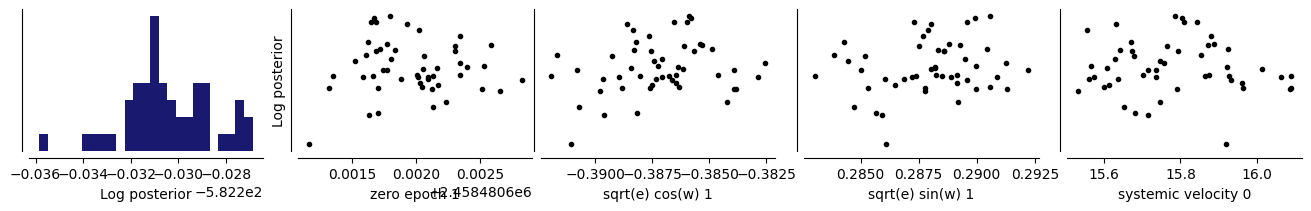

In [22]:
lpf.optimize_global(2000)
"""busca el mejor punto de partida para el MCMC. Encuentra el pico de distribución"""

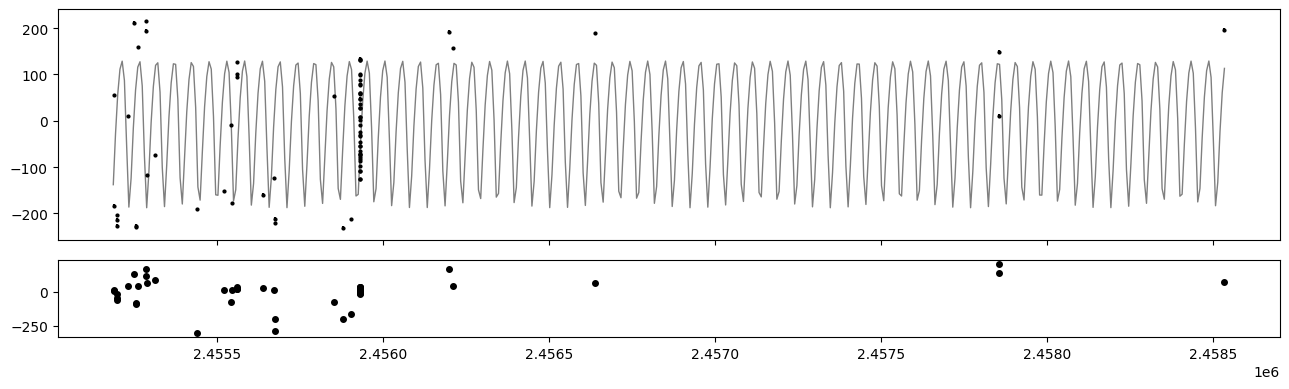

In [23]:
lpf.plot_rv_vs_time();
"""muestra los datos de velocidad radial en función del tiempo, junto con la mejor curva ajustada tras la optimización"""

/home/alba/anaconda3/envs/exoexo/lib/python3.10/site-packages/pytransit/lpf/rvlpf.py:370: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  axs[0].errorbar(phase[m], rvs[m], self._rvea[m], fmt='o', marker=markers[iid],


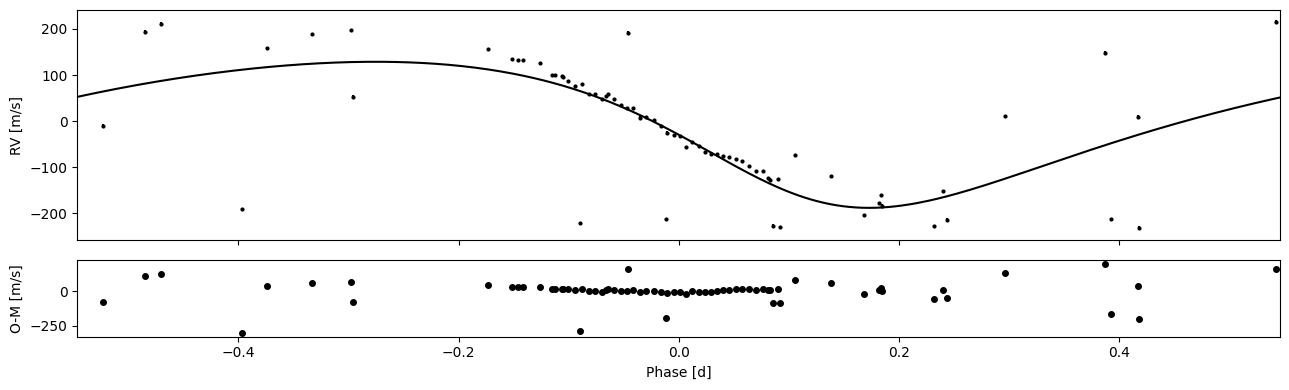

In [24]:
lpf.plot_rv_vs_phase(0);
"""aquí ajusta en función de la fase orbital, es decir, el tiempo plegado sobre el periodo. 
Todos los puntos de distintas épocas se superponen en una sola curva.
La amplitud de dicha curva representa el valor 2K"""

### Estimate the parameter posterior distributions using MCMC

We estimate the [posterior probability distributions](https://en.wikipedia.org/wiki/Posterior_probability) of our model parameters using [Markov Chain Monte Carlo sampling](https://twiecki.io/blog/2015/11/10/mcmc-sampling). The sampling can be done using the `RVLPF.sample_mcmc` method after a global optimisation run has been finished. The `sample_mcmc` method uses the [*emcee*](https://emcee.readthedocs.io/en/stable) sampler under the hood.

We give `RVLPF.sample_mcmc` the number of MCMC steps to take (`niter`), a thinning factor (`thin`), and a number of repeats (`repeats`). This makes the sampler run first one round of `niter` steps, restarts the sampler from the last step of the previous run, and run again `niter` steps. This is the same as running the sampler for `2 x niter` and keeping only the second half of the steps. The first half is treated as a [warm-up period](https://stats.stackexchange.com/questions/88819/mcmc-methods-burning-samples) for the sampler and discarded. In general, the sampler is run `repeats x niter` steps in total, and only the last `niter` steps are retained.

The thinning factor tells the sampler to store only every $n$th step. In our case, we're storing only every 10th step. Thinning is a way to try to store only statistically independent samples, but is [not really necessary](https://besjournals.onlinelibrary.wiley.com/doi/pdf/10.1111/j.2041-210X.2011.00131.x). However, we'll do it to keep the number of samples low (there's no point in storing a large number of dependent samples either).

In [25]:
lpf.sample_mcmc(niter=2000, thin=10, repeats=2)

MCMC sampling: 100%|██████████████████████████████| 2/2 [00:15<00:00,  7.59s/it]


The *emcee* sampler uses an ensemble of MCMC chains to sample the posterior. This means that we have many chains running in parallel. We can plot the traces of each chain to see how the chain population behaves in time.

'trazas de las cadenas MCMC.\nMuestra cómo evoluciona el valor de cada parámetros a lo largo de las iteraciones del MCMC, para cada cadena'

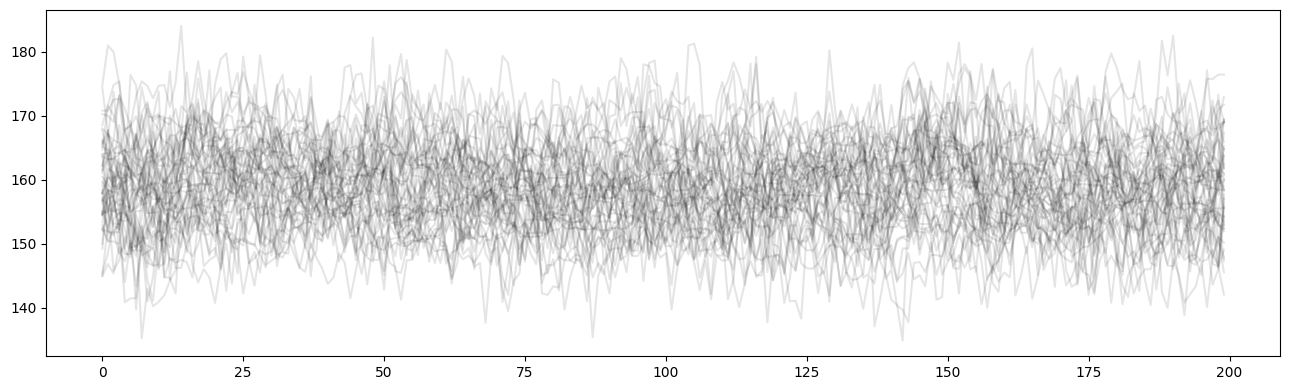

In [26]:
lpf.plot_mcmc_chains(6);
"""trazas de las cadenas MCMC.
Muestra cómo evoluciona el valor de cada parámetros a lo largo de las iteraciones del MCMC, para cada cadena"""

### Plot the model posterior

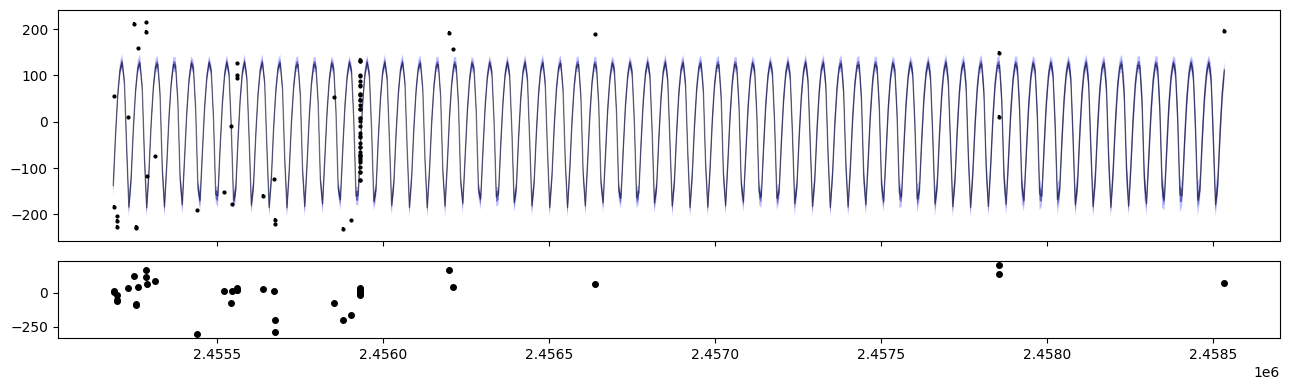

In [27]:
lpf.plot_rv_vs_time('mcmc');

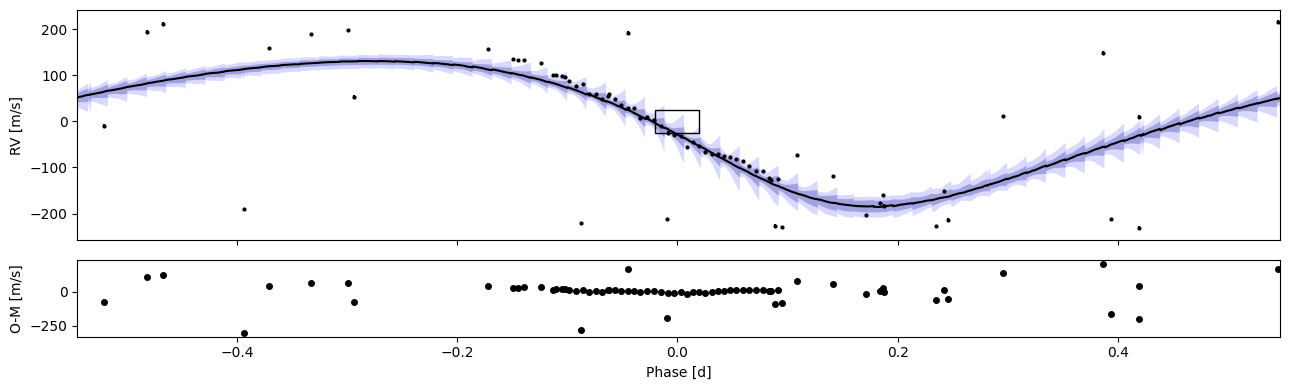

In [28]:
fig = lpf.plot_rv_vs_phase(0, 'mcmc')
fig.axes[0].add_patch(Rectangle((-.02, -25), 0.04, 50, fill=False));
"""se centra en la fase 0, momento del tránsito, para ver con detalle cómo el modelo cruza por el cero. Las sobras son la incertidumbre"""

When we zoom a little bit, we can see that we're now actually plotting the probability density of the model. The black line corresponds to the median of the model posterior, and the two shades to the 68% and 95% central posterior limits.

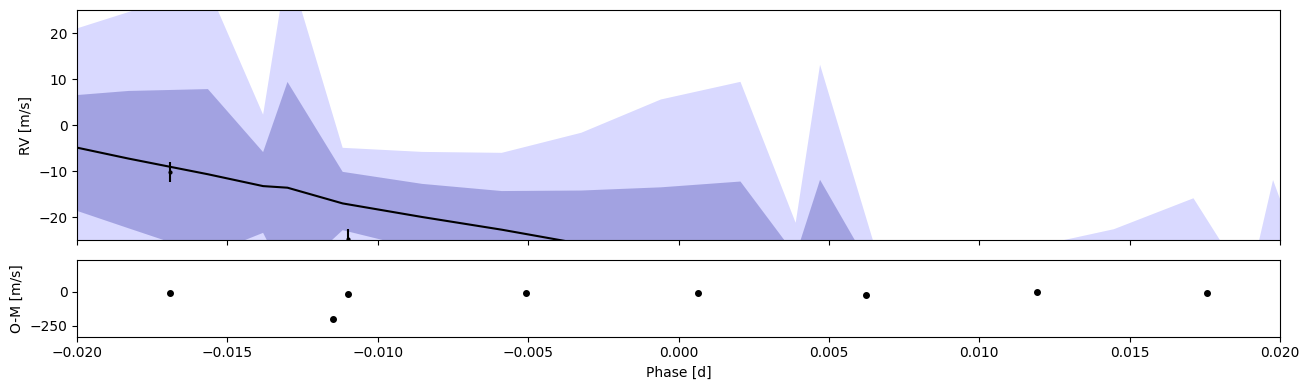

In [30]:
fig = lpf.plot_rv_vs_phase(0, 'mcmc')
setp(fig.axes[0], xlim=(-0.02, 0.02), ylim=(-25,25));

### Plot the parameter posteriors

In [31]:
df = lpf.posterior_samples()
df

,tc_1,p_1,secw_1,sesw_1,rv_shift_0,rv_err_0,rv_k_1,rv_slope_1
0,2.458481e+06,1.094671,-0.336611,0.353149,6.115585,29.956384,154.830618,0.000004
1,2.458481e+06,1.094666,-0.369717,0.330763,3.312020,29.972877,152.461658,0.000001
2,2.458481e+06,1.094666,-0.353922,0.324604,3.809888,29.978153,155.252254,0.000005
3,2.458481e+06,1.094651,-0.439096,0.195254,17.751555,29.994110,155.446217,0.000002
4,2.458481e+06,1.094652,-0.450940,0.170565,16.439128,29.981023,160.600894,0.000002
...,...,...,...,...,...,...,...,...
9995,2.458481e+06,1.094651,-0.446189,0.172588,17.639880,29.960117,164.289756,0.000007
9996,2.458481e+06,1.094660,-0.401064,0.224933,14.253535,29.951104,150.375963,0.000010
9997,2.458481e+06,1.094670,-0.357157,0.250584,15.713575,29.967936,143.594058,0.000009
9998,2.458481e+06,1.094663,-0.421875,0.230260,15.724126,29.959230,145.998336,0.000003


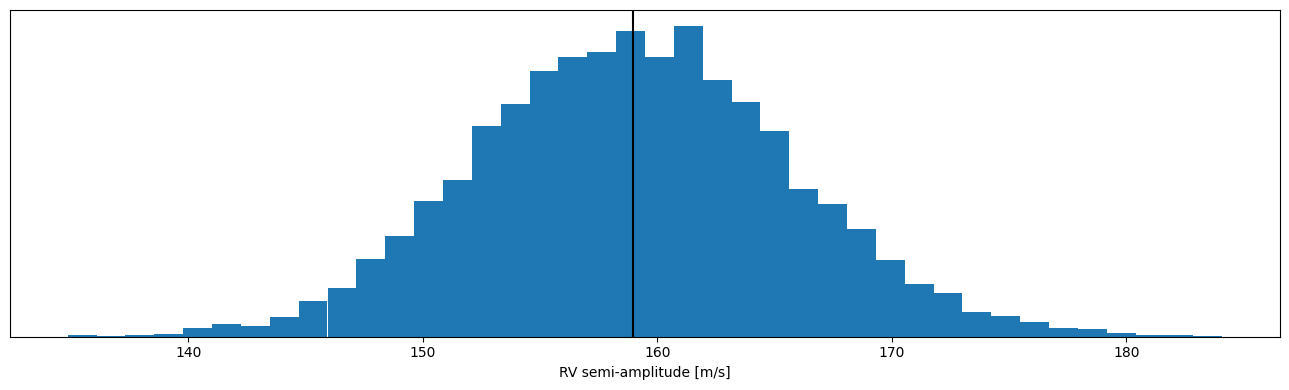

In [32]:
fig, ax = subplots()
ax.hist(df.rv_k_1, bins=40)
ax.axvline(median(df.rv_k_1), c='k')
setp(ax, xlabel='RV semi-amplitude [m/s]', yticks=[])
fig.tight_layout()

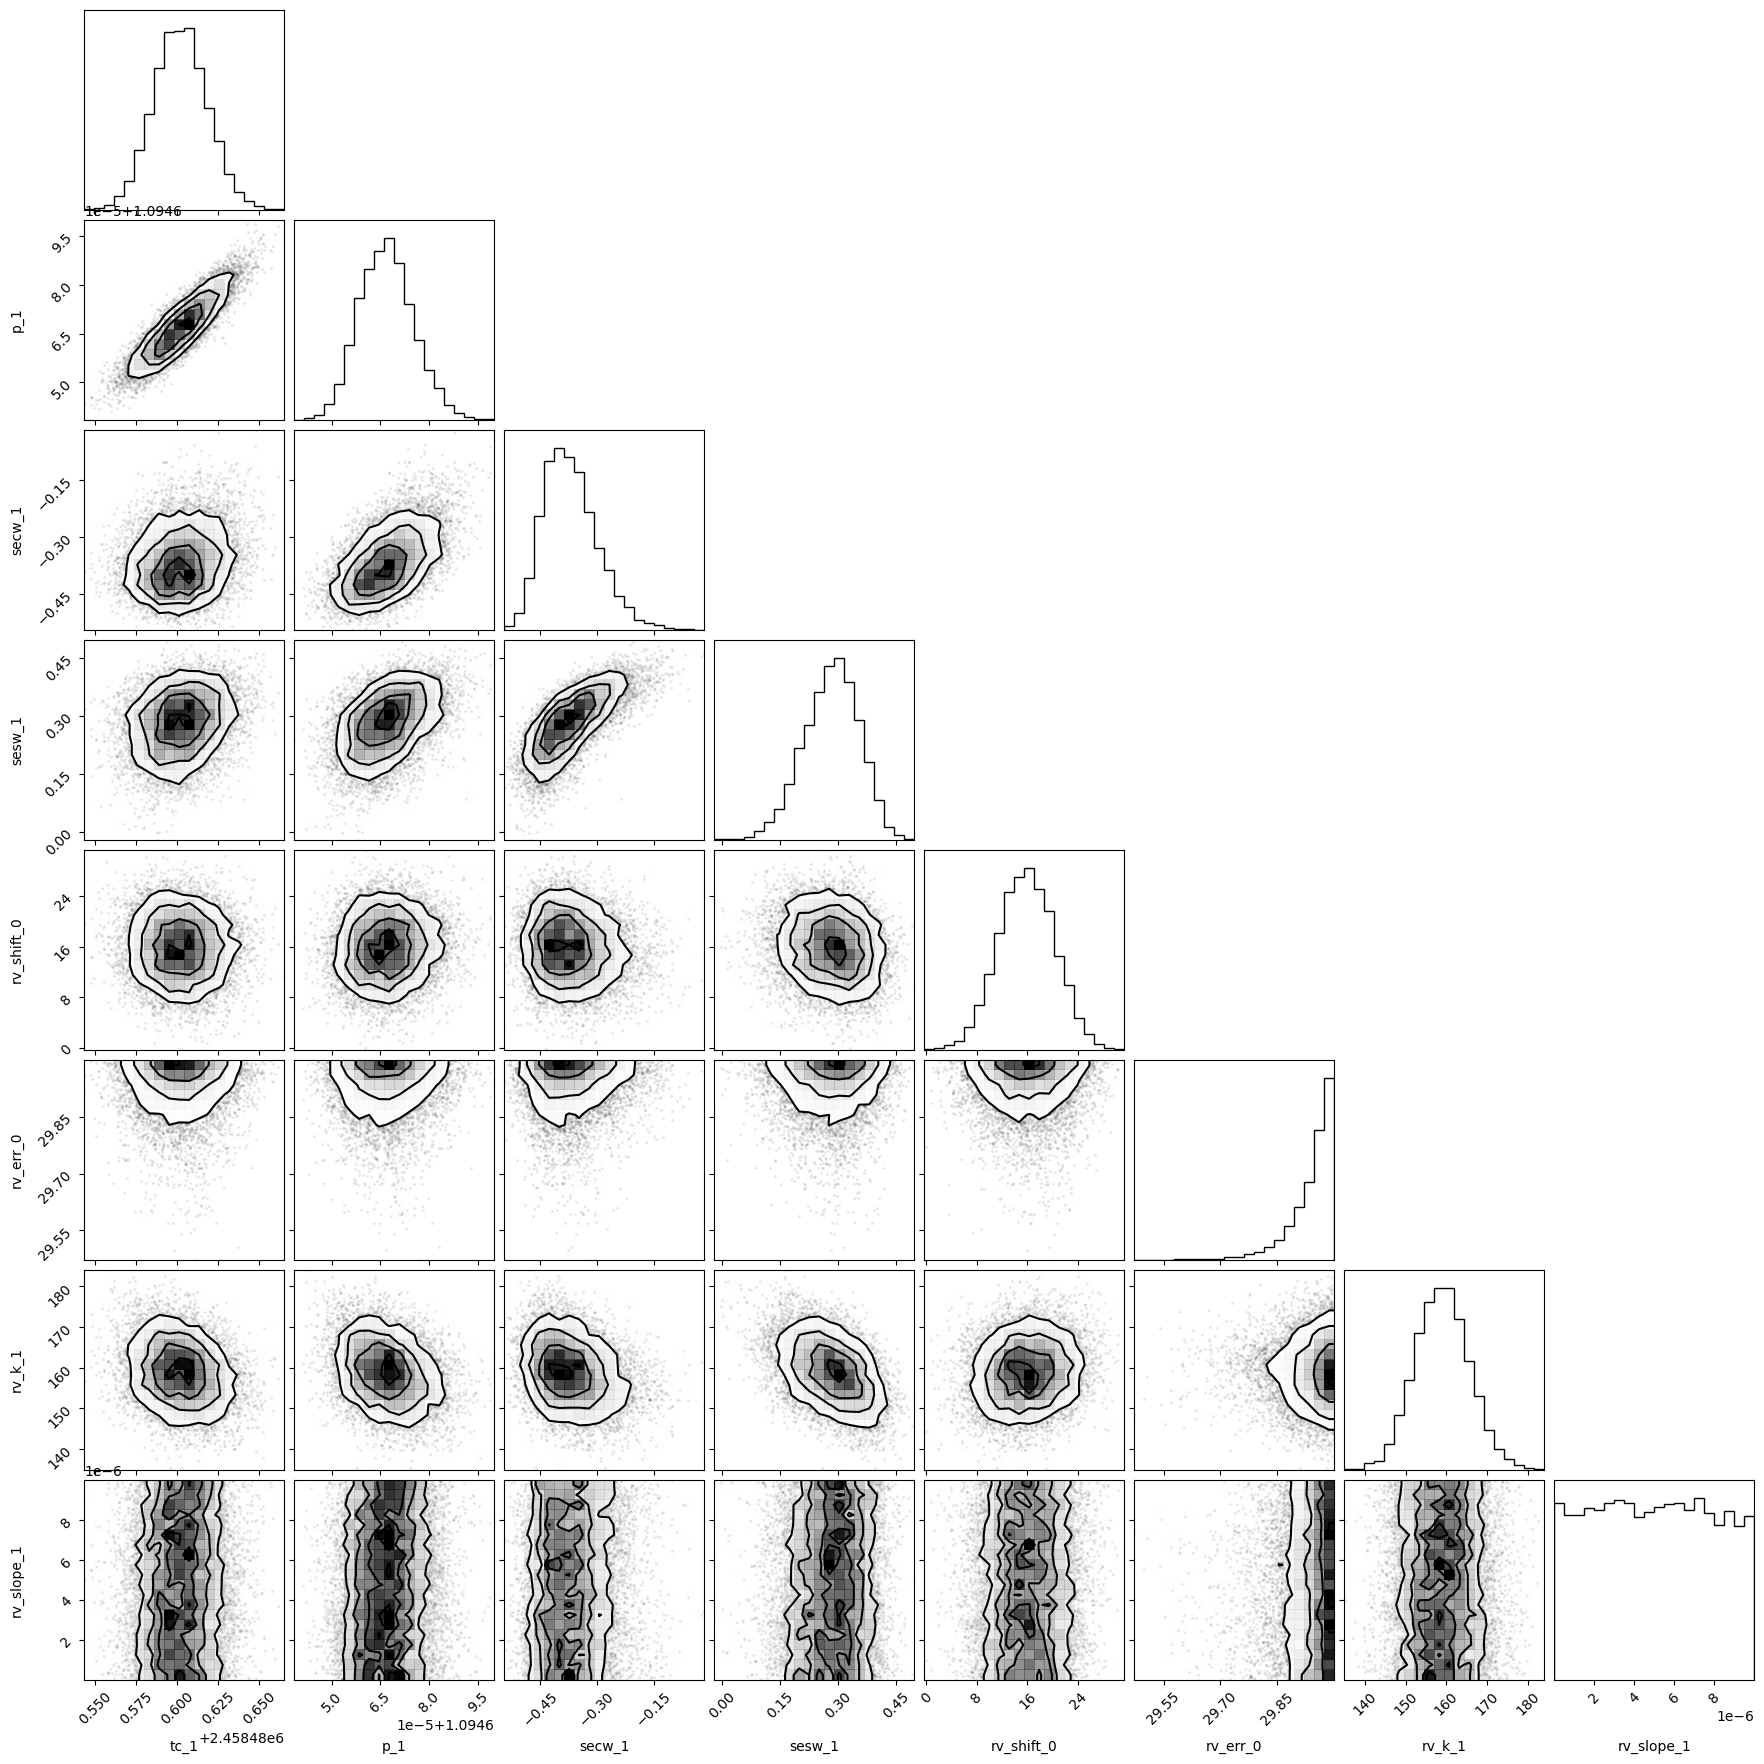

In [33]:
corner(df.values, labels=df.columns);

### <span style="color:darkblue">Questions and exercises</span>

1. What is the posterior density for the minimum mass ($m\sin i$) of WASP-12b? You can derive this from the RV semi-amplitude (K), orbital period (p), and the host star mass.

Derive the equation for the minimum mass, do the calculations using posterior samples, report both the mass median and its 68th percentile uncertainties, and plot the distribution. Use astropy constants, units, and unit conversions where needed.

Minimum mass of WASP-12b:
  M·sin(i) = 1.025 +0.042 / -0.042  M_Jup


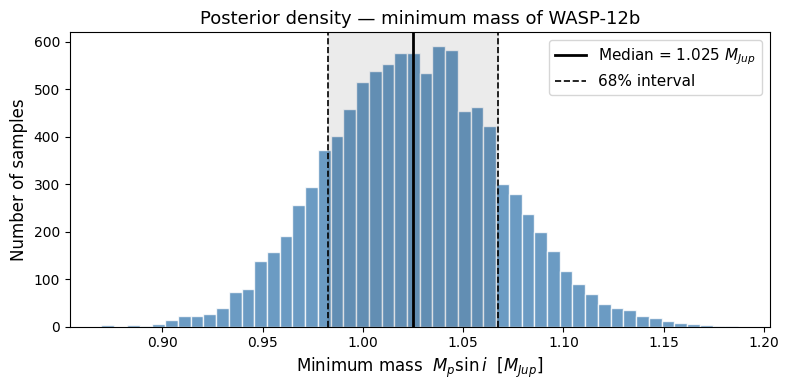

In [35]:
from astropy.constants import G, M_sun, M_jup
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from numpy import median, percentile

# ── 1. Parámetros del sistema ──────────────────────────────────────────────
M_star = 1.434 * M_sun   # masa de WASP-12 (Hebb et al. 2009)

# ── 2. Extraer muestras MCMC ───────────────────────────────────────────────
K = df['rv_k_1'].values * (u.m / u.s)   # semi-amplitud [m/s]
P = df['p_1'].values * u.day            # período orbital [días]

# ── 3. Ecuación de la masa mínima ─────────────────────────────────────────
# Derivada de la ecuación de K asumiendo Mp << M_star:
#
#        K · (P · M_star²)^(1/3)
#  Mp·sin(i) = ─────────────────────
#               (2π G)^(1/3)

M_min = (K * (P * M_star**2 / (2 * np.pi * G))**(1/3)).to(u.M_jup)

# ── 4. Estadísticos ────────────────────────────────────────────────────────
med   = median(M_min.value)
low   = med - percentile(M_min.value, 16)   # -1σ
high  = percentile(M_min.value, 84) - med   # +1σ

print(f"Minimum mass of WASP-12b:")
print(f"  M·sin(i) = {med:.3f} +{high:.3f} / -{low:.3f}  M_Jup")

# ── 5. Plot ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(M_min.value, bins=50, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(med,                    color='black', lw=2,   label=f'Median = {med:.3f} $M_{{Jup}}$')
ax.axvline(med - low,              color='black', lw=1.2, ls='--', label='68% interval')
ax.axvline(med + high,             color='black', lw=1.2, ls='--')
ax.axvspan(med - low, med + high,  color='black', alpha=0.08)

ax.set_xlabel(r'Minimum mass  $M_p \sin i$  [$M_{Jup}$]', fontsize=12)
ax.set_ylabel('Number of samples', fontsize=12)
ax.set_title('Posterior density — minimum mass of WASP-12b', fontsize=13)
ax.legend(fontsize=11)
fig.tight_layout()

2. What can you tell about WASP-12b as a planet based on its minimum mass and orbital period?

- WASP-12b is a planet similar to Jupiter but hotter. We know it is hotter because it's a Jupiter-mass on a tight orbit. Using Kepler's third law, I calculated the orbital distance to its star, and it corresponds to 0.023 AU, so it is extremely expose to stellar radiation and strong tidal forces coming from the near star WASP-12.

3. We parameterise the model using ($\sqrt{e}\sin\omega$, $\sqrt{e}\cos\omega$) instead of ($e$, $\omega$). This parameterisation is more efficient to sample with an MCMC sampler, but means we need to take some extra steps to get the eccentricity and argument of periastron samples. Write below the equations you need to use to map the sampling parameters to $e$ and $\omega$?

### Q3 — Parameter transformation: $(\sqrt{e}\sin\omega,\ \sqrt{e}\cos\omega) \rightarrow (e,\ \omega)$

### Derivation of $e$

Starting from the two sampled parameters:

$$
x^2 + y^2 = \left(\sqrt{e}\sin\omega\right)^2 + \left(\sqrt{e}\cos\omega\right)^2
$$

$$
x^2 + y^2 = e\sin^2\omega + e\cos^2\omega
$$

$$
x^2 + y^2 = e\left(\sin^2\omega + \cos^2\omega\right)
$$

Using the Pythagorean identity $\sin^2\omega + \cos^2\omega = 1$:

$$
\boxed{e = x^2 + y^2 = \left(\sqrt{e}\sin\omega\right)^2 + \left(\sqrt{e}\cos\omega\right)^2}
$$

### Derivation of $\omega$

Taking the ratio of the two sampled parameters:

$$
\frac{x}{y} = \frac{\sqrt{e}\sin\omega}{\sqrt{e}\cos\omega} = \frac{\sin\omega}{\cos\omega} = \tan\omega
$$

Therefore:

$$
\omega = \arctan\left(\frac{x}{y}\right) = \arctan\left(\frac{\sqrt{e}\sin\omega}{\sqrt{e}\cos\omega}\right)
$$



4. Derive $e$ and $\omega$ from the MCMC samples and plot their histograms.

Eccentricity:           e = 0.2256 +0.0333 / -0.0326
Argument of periastron: ω = 142.92 +11.03 / -11.83 deg


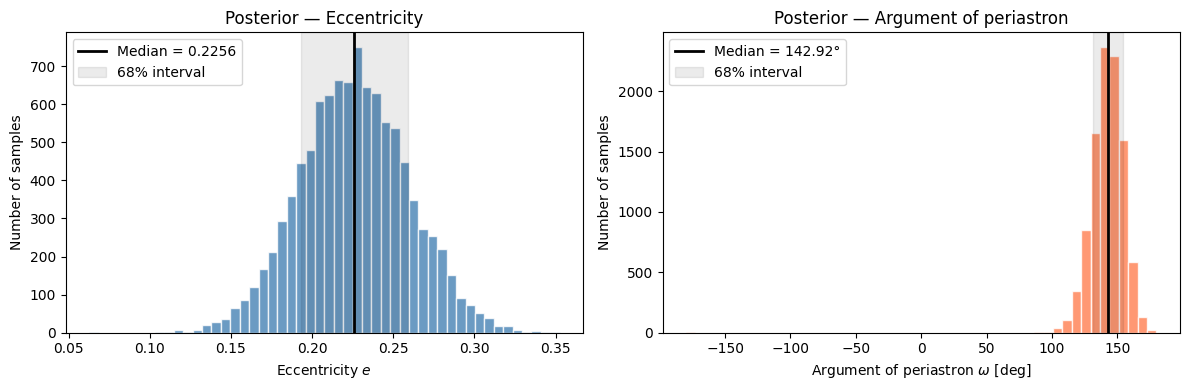

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots, setp
from numpy import median, percentile

# ── 1. Extract sampling parameters from posterior ──────────────────────────
sesw = df['sesw_1'].values   # sqrt(e)*sin(omega)
secw = df['secw_1'].values   # sqrt(e)*cos(omega)

# ── 2. Derive e and omega ──────────────────────────────────────────────────
e     = sesw**2 + secw**2
omega = np.degrees(np.arctan2(sesw, secw))  # convert to degrees

# ── 3. Statistics ──────────────────────────────────────────────────────────
e_med   = median(e)
e_low   = e_med - percentile(e, 16)
e_high  = percentile(e, 84) - e_med

w_med   = median(omega)
w_low   = w_med - percentile(omega, 16)
w_high  = percentile(omega, 84) - w_med

print(f"Eccentricity:           e = {e_med:.4f} +{e_high:.4f} / -{e_low:.4f}")
print(f"Argument of periastron: ω = {w_med:.2f} +{w_high:.2f} / -{w_low:.2f} deg")

# ── 4. Plot ────────────────────────────────────────────────────────────────
fig, axs = subplots(1, 2, figsize=(12, 4))

# Eccentricity
axs[0].hist(e, bins=50, color='steelblue', alpha=0.8, edgecolor='white')
axs[0].axvline(e_med, color='black', lw=2, label=f'Median = {e_med:.4f}')
axs[0].axvspan(e_med - e_low, e_med + e_high, color='black', alpha=0.08, label='68% interval')
setp(axs[0], xlabel='Eccentricity $e$', ylabel='Number of samples', title='Posterior — Eccentricity')
axs[0].legend()

# Argument of periastron
axs[1].hist(omega, bins=50, color='coral', alpha=0.8, edgecolor='white')
axs[1].axvline(w_med, color='black', lw=2, label=f'Median = {w_med:.2f}°')
axs[1].axvspan(w_med - w_low, w_med + w_high, color='black', alpha=0.08, label='68% interval')
setp(axs[1], xlabel='Argument of periastron $\\omega$ [deg]', ylabel='Number of samples', title='Posterior — Argument of periastron')
axs[1].legend()

fig.tight_layout()

5. What would be the posterior RV semi-amplitude of an Earth-mass planet orbiting WASP-12 with an orbital period of 365 days?

Analytical K : 0.07035 m/s
Posterior median K : 0.07035 m/s
Uncertainty        : +0.00000017 / -0.00000018 m/s
Relative uncertainty: 0.00025 %


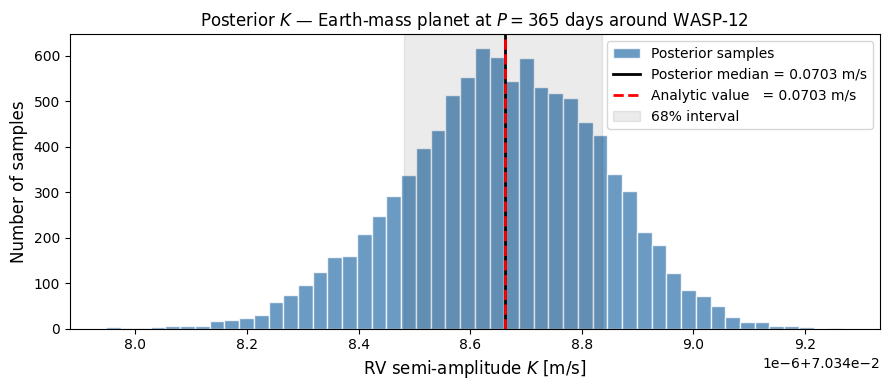

In [56]:
from astropy.constants import G, M_sun, M_earth
import numpy as np
import matplotlib.pyplot as plt
from numpy import median, percentile

# ── 1. Constants in SI (pure floats) ──────────────────────────────────────
M_star_kg = (1.434 * M_sun).to('kg').value
M_p_kg    = M_earth.to('kg').value
P_earth_s = (365.25 * 86400)               # seconds
G_si      = G.value

# ── 2. Analytical K ────────────────────────────────────────────────────────
K_analytic = M_p_kg * (2 * np.pi * G_si / (P_earth_s * M_star_kg**2))**(1/3)
print(f"Analytical K : {K_analytic:.5f} m/s")

# ── 3. Posterior samples — propagate P uncertainty from MCMC ───────────────
P_samples_s = df['p_1'].values * 86400        # posterior P samples in seconds
P_med = median(P_samples_s)
P_scatter = P_samples_s - P_med              # deviations from median
K_earth_samples = K_analytic * (1 - (1/3) * P_scatter / P_med)

# ── 4. Statistics ──────────────────────────────────────────────────────────
K_med  = median(K_earth_samples)
K_low  = K_med - percentile(K_earth_samples, 16)
K_high = percentile(K_earth_samples, 84) - K_med

print(f"Posterior median K : {K_med:.5f} m/s")
print(f"Uncertainty        : +{K_high:.8f} / -{K_low:.8f} m/s")
print(f"Relative uncertainty: {((K_high+K_low)/2/K_med)*100:.5f} %")

# ── 5. Plot ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(K_earth_samples, bins=50,
        color='steelblue', alpha=0.8, edgecolor='white',
        label='Posterior samples')

ax.axvline(K_med, color='black', lw=2,
           label=f'Posterior median = {K_med:.4f} m/s')
ax.axvline(K_analytic, color='red', lw=2, ls='--',
           label=f'Analytic value   = {K_analytic:.4f} m/s')
ax.axvspan((K_med - K_low), (K_med + K_high),
           color='black', alpha=0.08, label='68% interval')

ax.set_xlabel('RV semi-amplitude $K$ [m/s]', fontsize=12)
ax.set_ylabel('Number of samples', fontsize=12)
ax.set_title('Posterior $K$ — Earth-mass planet at $P = 365$ days around WASP-12',
             fontsize=12)
ax.legend(fontsize=10)
fig.tight_layout()

---

<center>&copy;2026 Hannu Parviainen</center>